<a href="https://colab.research.google.com/github/elvisvaquerano/machine-learning-assignment/blob/main/house_price_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Number of houses: 1460
   square_footage location   price
0            1710  CollgCr  208500
1            1262  Veenker  181500
2            1786  CollgCr  223500
3            1717  Crawfor  140000
4            2198  NoRidge  250000
Predicted price for a 2000 sq ft house in NAmes: $199,439.21

Model Coefficients:
location_Blmngtn: 15916.57
location_Blueste: -36576.67
location_BrDale: -51780.44
location_BrkSide: -34350.03
location_ClearCr: 16301.31
location_CollgCr: 19492.68
location_Crawfor: 7062.28
location_Edwards: -40751.05
location_Gilbert: 2269.27
location_IDOTRR: -49248.61
location_MeadowV: -52983.05
location_Mitchel: -9646.37
location_NAmes: -20084.98
location_NPkVill: -17811.23
location_NWAmes: -9598.79
location_NoRidge: 70532.32
location_NridgHt: 97818.13
location_OldTown: -53131.10
location_SWISU: -62843.19
location_Sawyer: -22004.41
location_SawyerW: -4096.70
location_Somerst: 38318.51
location_StoneBr: 96251.05
location_Timber: 37058.39
location_Veenker: 63886.12
square_foo

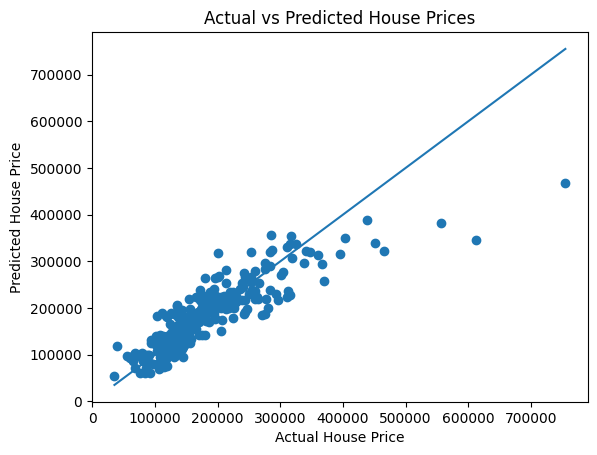

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
# Generate sample data
df = pd.read_csv("train.csv")

# Select square footage, location, and house price
df = df[['GrLivArea', 'Neighborhood', 'SalePrice']]

# Rename columns to match the starter code
df = df.rename(columns={
    'GrLivArea': 'square_footage',
    'Neighborhood': 'location',
    'SalePrice': 'price'
})

# Remove any rows with missing values
df = df.dropna()

# Display dataset information
print("Number of houses:", len(df))
print(df.head())
# Features and target
X = df[['square_footage', 'location']]
y = df['price']
# Preprocessing: One-hot encode the location column
preprocessor = ColumnTransformer(
transformers=[
('location', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), ['location'])
], remainder='passthrough')
# Create pipeline with preprocessing and model
model = Pipeline(steps=[
('preprocessor', preprocessor),
('regressor', LinearRegression())
])
# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
random_state=42)
# Train model
model.fit(X_train, y_train)
# Make prediction for a new house: 2000 sq ft in NAmes neighborhood
new_house = pd.DataFrame({
    'square_footage': [2000],
    'location': ['NAmes']
})

predicted_price = model.predict(new_house)

print(f"Predicted price for a 2000 sq ft house in NAmes: ${predicted_price[0]:,.2f}")
# Display model coefficients
feature_names = (model.named_steps['preprocessor'] \
.named_transformers_['location'] \
.get_feature_names_out(['location'])).tolist() + \
['square_footage']
coefficients = model.named_steps['regressor'].coef_
print("\nModel Coefficients:")
for feature, coef in zip(feature_names, coefficients):
    print(f"{feature}: {coef:.2f}")

# Evaluate the model on the test set
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\nModel Evaluation:")
print(f"Mean Absolute Error: ${mae:,.2f}")
print(f"Root Mean Squared Error: ${rmse:,.2f}")
print(f"R-squared Score: {r2:.3f}")

# Visualize actual vs predicted prices
plt.scatter(y_test, y_pred)
plt.xlabel("Actual House Price")
plt.ylabel("Predicted House Price")
plt.title("Actual vs Predicted House Prices")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)

plt.show()